In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['image.cmap'] = 'bwr'

from src import *

In [3]:
Y = list(range(2**9))

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

# Experiment 3

Hypothesis:

- Uniform $\mathcal{X}$ distribution (shouldn't impact the results)
- The ground truth $y$ images are drawn from handcrafted probability distributions
- Output probability distribution is known, i.e., $\forall y$, we can compute $P(Y=y|X=x)$

## Singleton distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly and is assigned a high probability (>0.5, uniformly sampled). This is the expert segmentation, and its probability is the experts' confidence level (maybe agreement?)
<!-- 2. Two other segmentations, $y^{(1)}$ and $y^{(2)}$, that differ from the expert segmentation by one pixel are assigned equal probability values ($P(Y=y^{(1)}|X=x) = P(Y=y^{(2)}|X=x)$) such that $$ P(Y=y^{\star}|X=x) + P(Y=y^{(1)}|X=x) + P(Y=y^{(2)}|X=x) = 1 $$ -->
2. One other segmentation, $y^{(1)}$, that differs from the expert segmentation by one pixel is assigned a probability value $$ P(Y=y^{(1)}|X=x) = 1 - P(Y=y^{\star}|X=x) $$

In [4]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)
    p_y_star = (np.random.RandomState(x).rand() + 1) / 2  # in [0.5, 1)

    y_1 = y_star ^ (2 ** np.random.RandomState(x).randint(0, 9))  # flip a random bit
    # y_2 = y_star ^ (2 ** np.random.RandomState((2**9)+x).randint(0, 9))

    # p_remaining = 1 - p_y_star
    # p_y_1 = np.random.RandomState(x**2).rand() * p_remaining
    # p_y_2 = p_remaining - p_y_1
    p_y_1 = 1 - p_y_star

    Py_x = np.zeros(2**9)
    Py_x[y_star] += p_y_star
    Py_x[y_1] += p_y_1
    # Py_x[y_2] += p_y_2
    Py.append(Py_x)

    # Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1 + int2img(y_2) * p_y_2
    Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

In [5]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

### Example

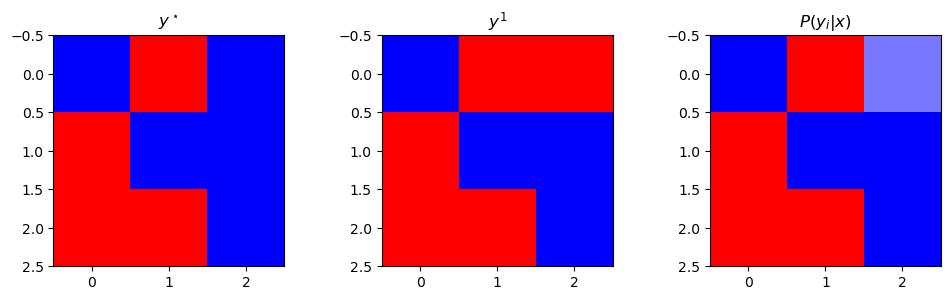

In [6]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])
# y_1, y_2 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]
y_1 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(int2img(y_1))
axs[1].set_title(r'$y^1$')

# axs[2].imshow(int2img(y_2))
# axs[2].set_title(r'$y^2$')

axs[2].imshow(Pyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$P(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [7]:
# most probable output
h = lambda x: np.argmax(Py[x])

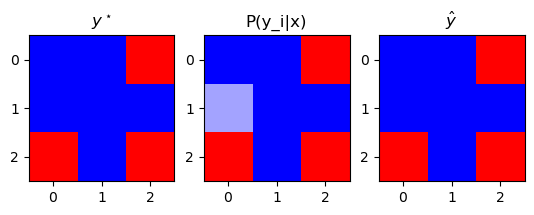

In [8]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

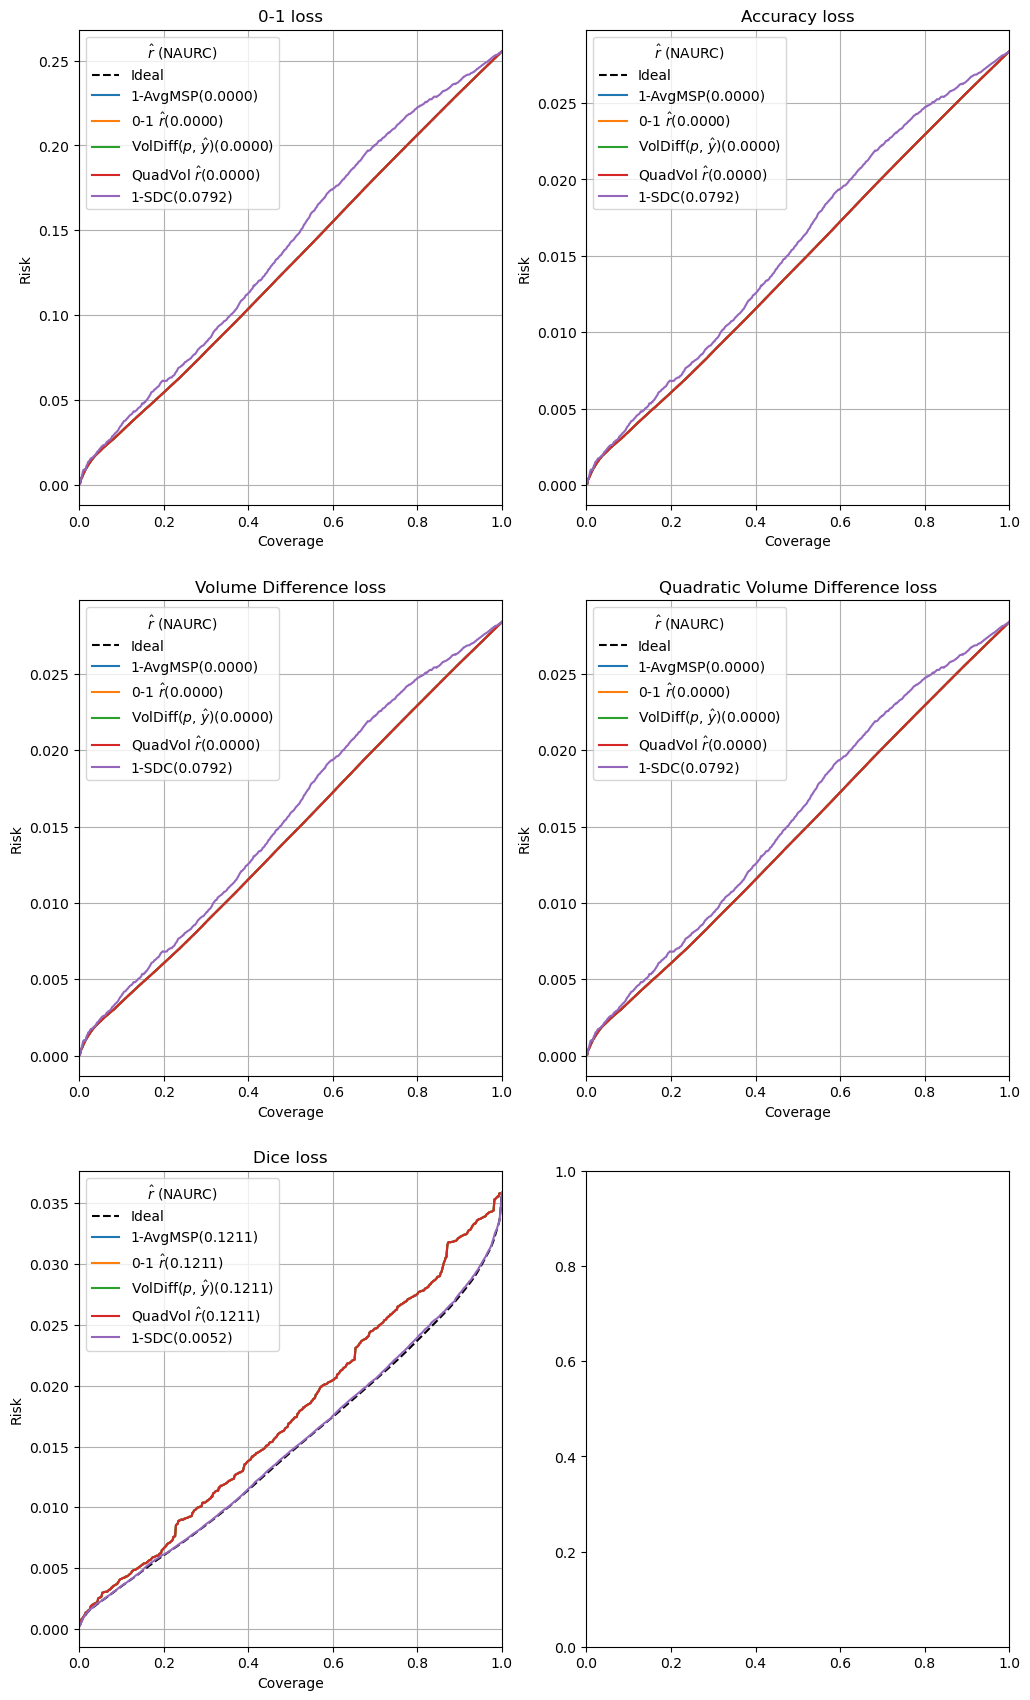

In [9]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

Note that 0-1, accuracy, AVE, and SVE have very similar behavior for the proposed probability distribution.

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [10]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

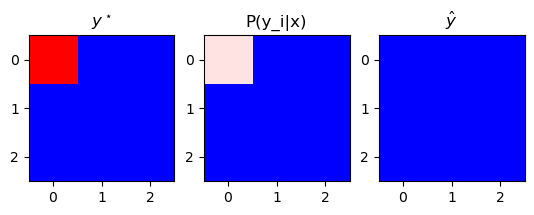

In [11]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

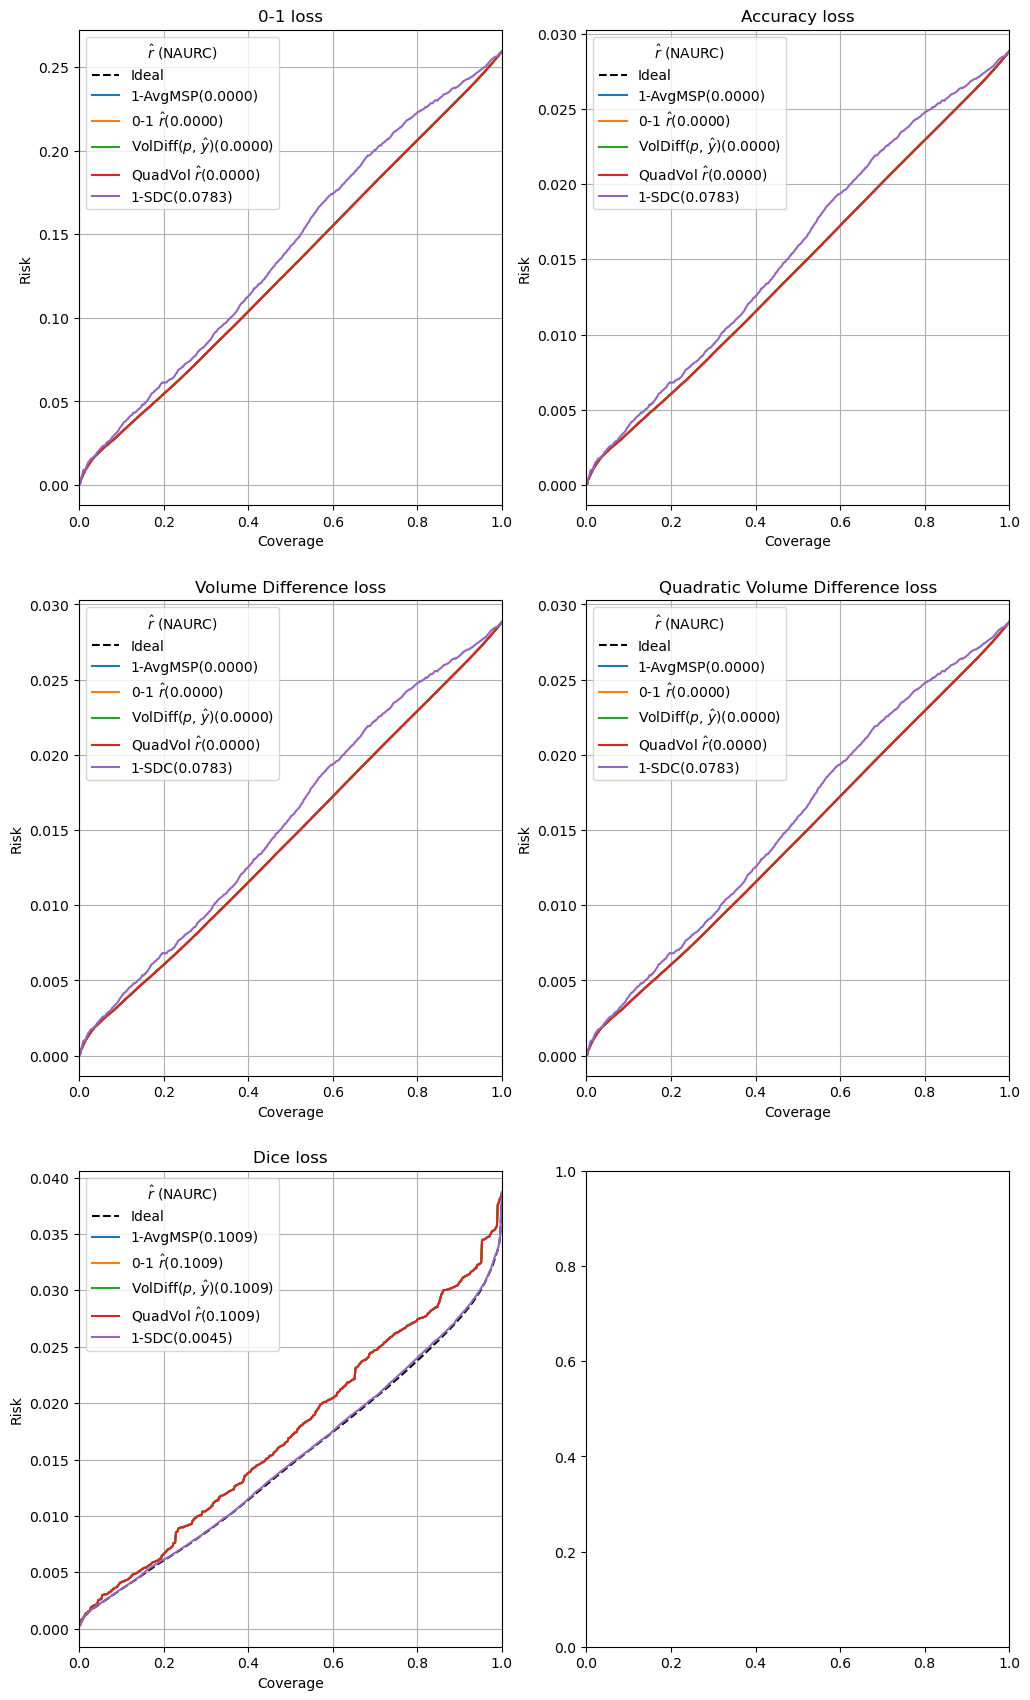

In [12]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Cherry-picked distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly and is assigned a high probability (>0.34, uniformly sampled). This is the expert segmentation, and its probability is the experts' confidence level (maybe agreement?)
2. Two other segmentations, $y^{(1)}$ and $y^{(2)}$, that differ from the expert segmentation by one pixel are assigned equal probability values ($P(Y=y^{(1)}|X=x) = P(Y=y^{(2)}|X=x)$) such that $$ P(Y=y^{\star}|X=x) + P(Y=y^{(1)}|X=x) + P(Y=y^{(2)}|X=x) = 1 $$
<!-- 2. One other segmentation, $y^{(1)}$, that differs from the expert segmentation by one pixel is assigned a probability value $$ P(Y=y^{(1)}|X=x) = 1 - P(Y=y^{\star}|X=x) $$ -->

In [13]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)
    p_y_star = (np.random.RandomState(x).rand() * (1 - 0.34)) + 0.34  # in [0.34, 1)

    y_1 = y_star ^ (2 ** np.random.RandomState(x).randint(0, 9))  # flip a random bit
    y_2 = y_star ^ (2 ** np.random.RandomState((2**9)+x).randint(0, 9))

    p_remaining = 1 - p_y_star
    p_y_1 = np.random.RandomState(x**2).rand() * p_remaining
    p_y_2 = p_remaining - p_y_1

    Py_x = np.zeros(2**9)
    Py_x[y_star] += p_y_star
    Py_x[y_1] += p_y_1
    Py_x[y_2] += p_y_2
    Py.append(Py_x)

    Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1 + int2img(y_2) * p_y_2
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

In [14]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

### Example

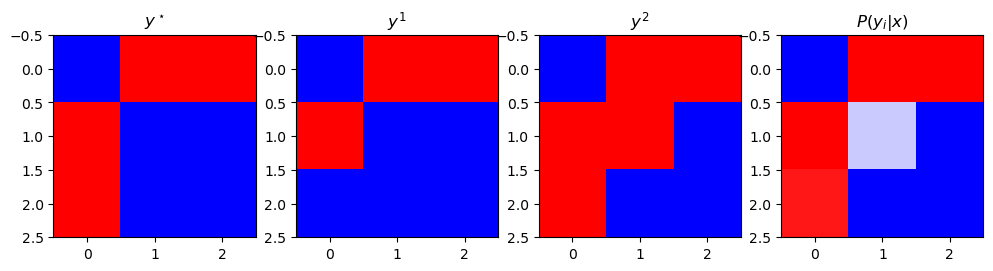

In [16]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 4)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])
y_1, y_2 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]
# y_1 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(int2img(y_1))
axs[1].set_title(r'$y^1$')

axs[2].imshow(int2img(y_2))
axs[2].set_title(r'$y^2$')

axs[3].imshow(Pyi[x], vmin=0, vmax=1)
axs[3].set_title(r'$P(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [17]:
# most probable output
h = lambda x: np.argmax(Py[x])

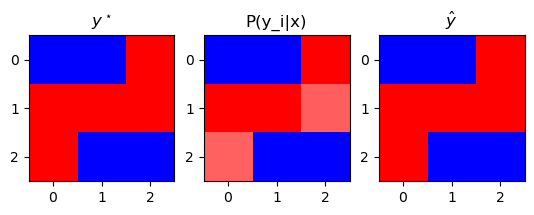

In [18]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

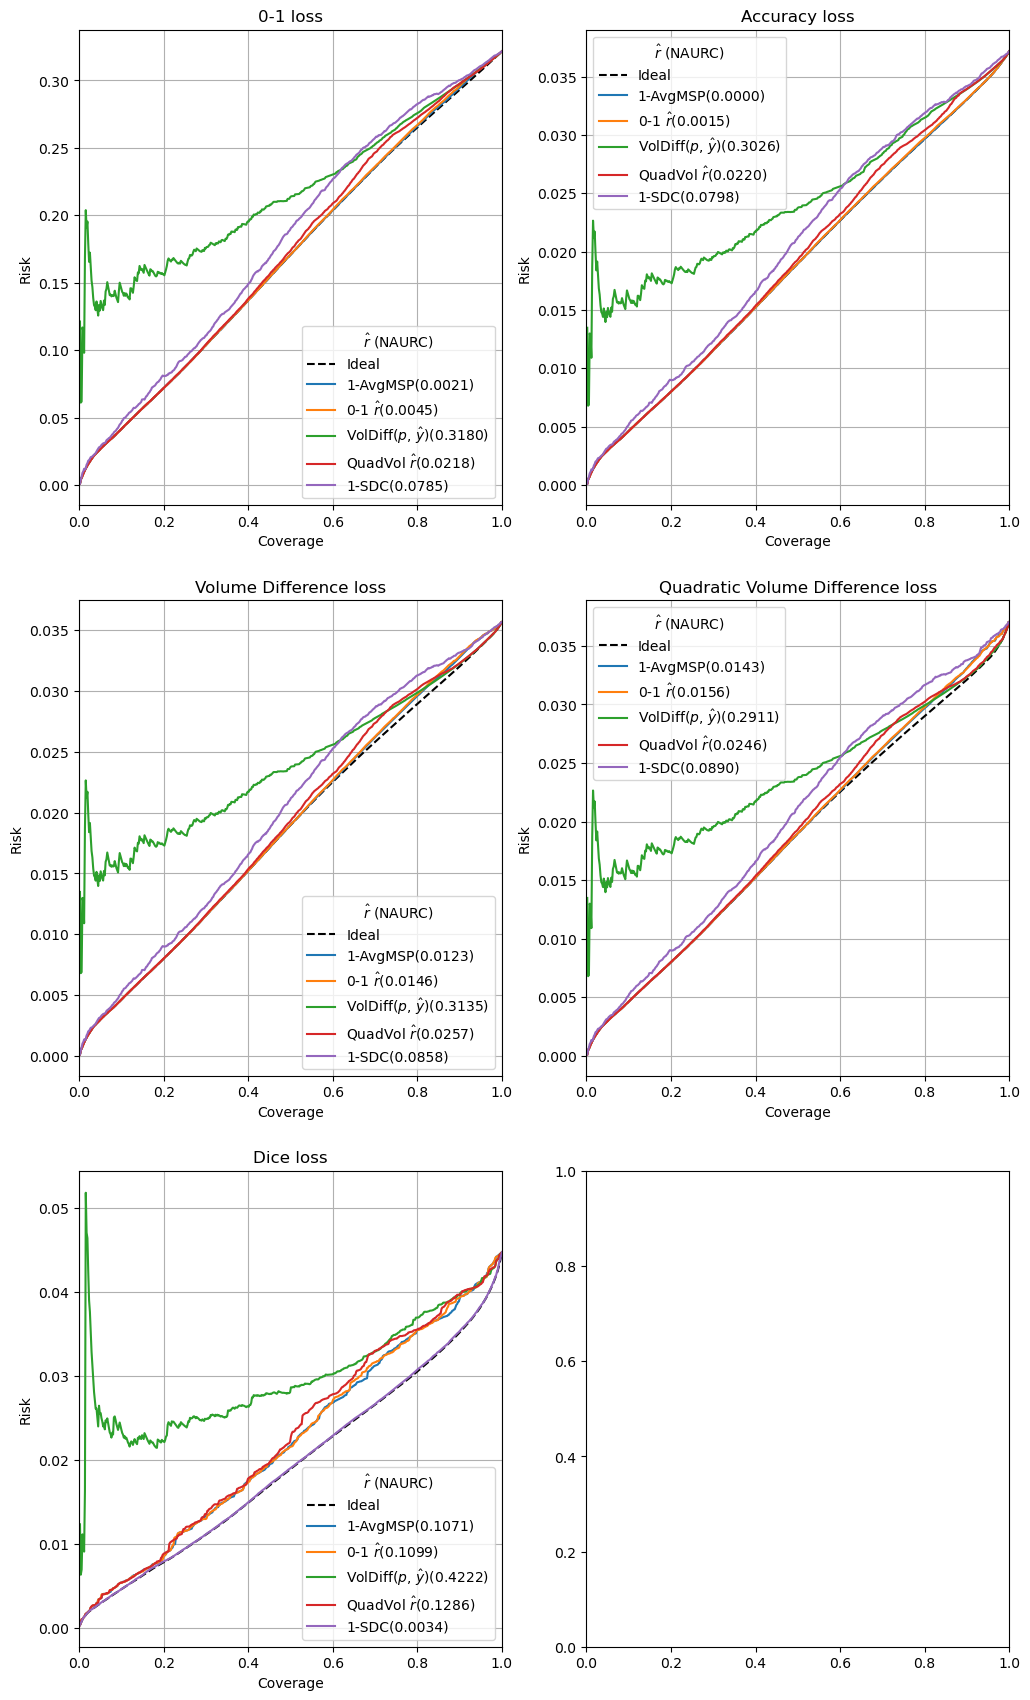

In [19]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

Note that 0-1, accuracy, AVE, and SVE have very similar behavior for the proposed probability distribution.

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [20]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

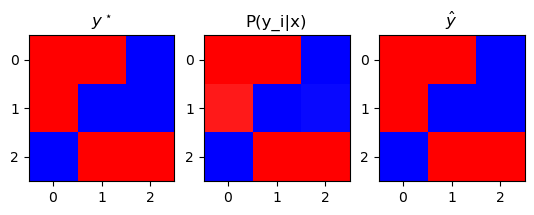

In [21]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

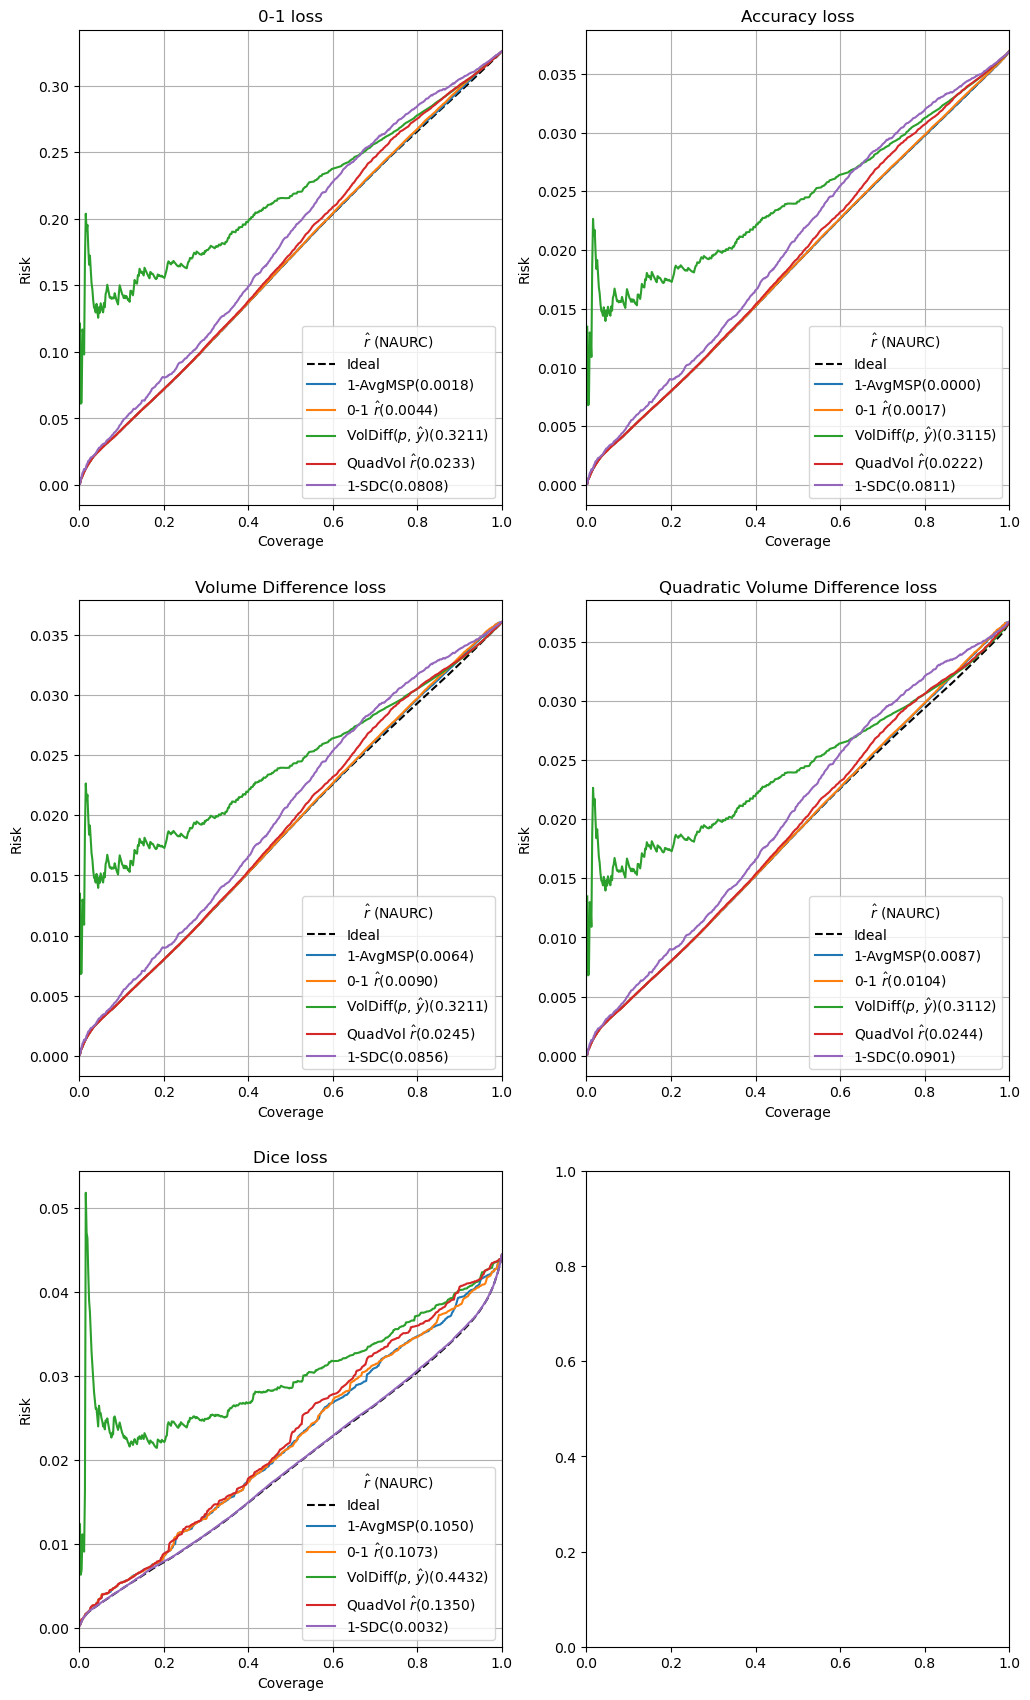

In [22]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## 1-pixel distance

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. Start with $p_y \gets 0,\,\forall y \in\mathcal{Y}$
1. Draw $y^{\star}$ uniformly and assign $p_{y^\star} \sim \mathcal{U}[0.34,1)$
1. $p' \gets 1 - \sum_{y\in\mathcal{Y}} P(Y=y|X=x)$
1. Pick $y\in\mathcal{Y}$ that differs from $y^\star$ by a single pixel
1. If $p' > 0.1$ then $p_y \gets p_y + \mathcal{U}[0.1,p']$ and goto step 3 else $p_y \gets p_y + p'$ 
1. $P(Y=y|X=x) \gets p_y$
<!-- 1. Two other segmentations, $y^{(1)}$ and $y^{(2)}$, that differ from the expert segmentation by one pixel are assigned equal probability values ($P(Y=y^{(1)}|X=x) = P(Y=y^{(2)}|X=x)$) such that $$ P(Y=y^{\star}|X=x) + P(Y=y^{(1)}|X=x) + P(Y=y^{(2)}|X=x) = 1 $$ -->
<!-- 2. One other segmentation, $y^{(1)}$, that differs from the expert segmentation by one pixel is assigned a probability value $$ P(Y=y^{(1)}|X=x) = 1 - P(Y=y^{\star}|X=x) $$ -->

In [23]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

for x in range(2**9):
    Py_x = np.zeros(2**9)

    y_star = np.random.RandomState(x).randint(1, 2**9)
    p_y_star = (np.random.RandomState(x).rand() * (1 - 0.34)) + 0.34  # in [0.34, 1)
    Py_x[y_star] = p_y_star

    p_remaining = 1 - p_y_star

    pixel_flips = 2 ** np.arange(9)
    np.random.RandomState(0).shuffle(pixel_flips)
    for pixel_flip in pixel_flips:
        y = y_star ^ pixel_flip
        if p_remaining > 0.1:
            Py_x[y] = np.random.RandomState(2**9 + x + pixel_flip).rand() * (p_remaining - 0.1) + 0.1
        else:
            Py_x[y] = p_remaining
        p_remaining = 1 - Py_x.sum()

    Py.append(Py_x)

    Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1 + int2img(y_2) * p_y_2
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

In [24]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

### Example

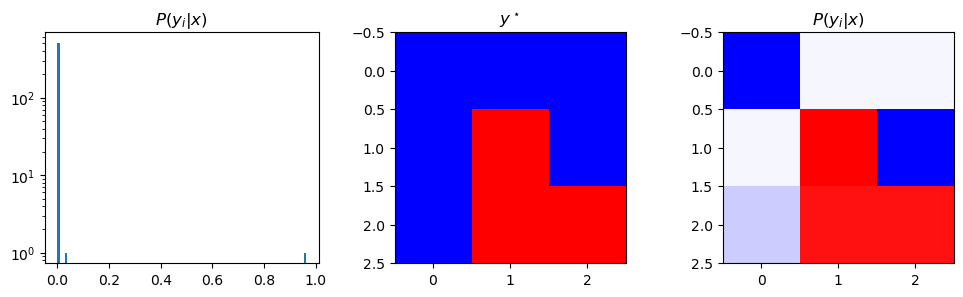

In [25]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])

axs[0].hist(Py[x], bins=100)
axs[0].set_yscale('log')
axs[0].set_title(r'$P(y_i|x)$')

axs[1].imshow(int2img(y_star))
axs[1].set_title(r'$y^\star$')

axs[2].imshow(Pyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$P(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [26]:
# most probable output
h = lambda x: np.argmax(Py[x])

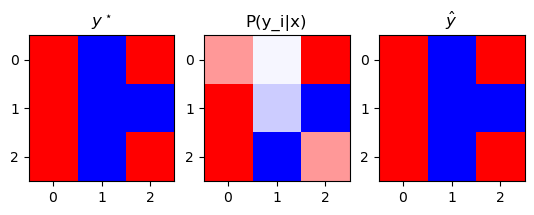

In [27]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

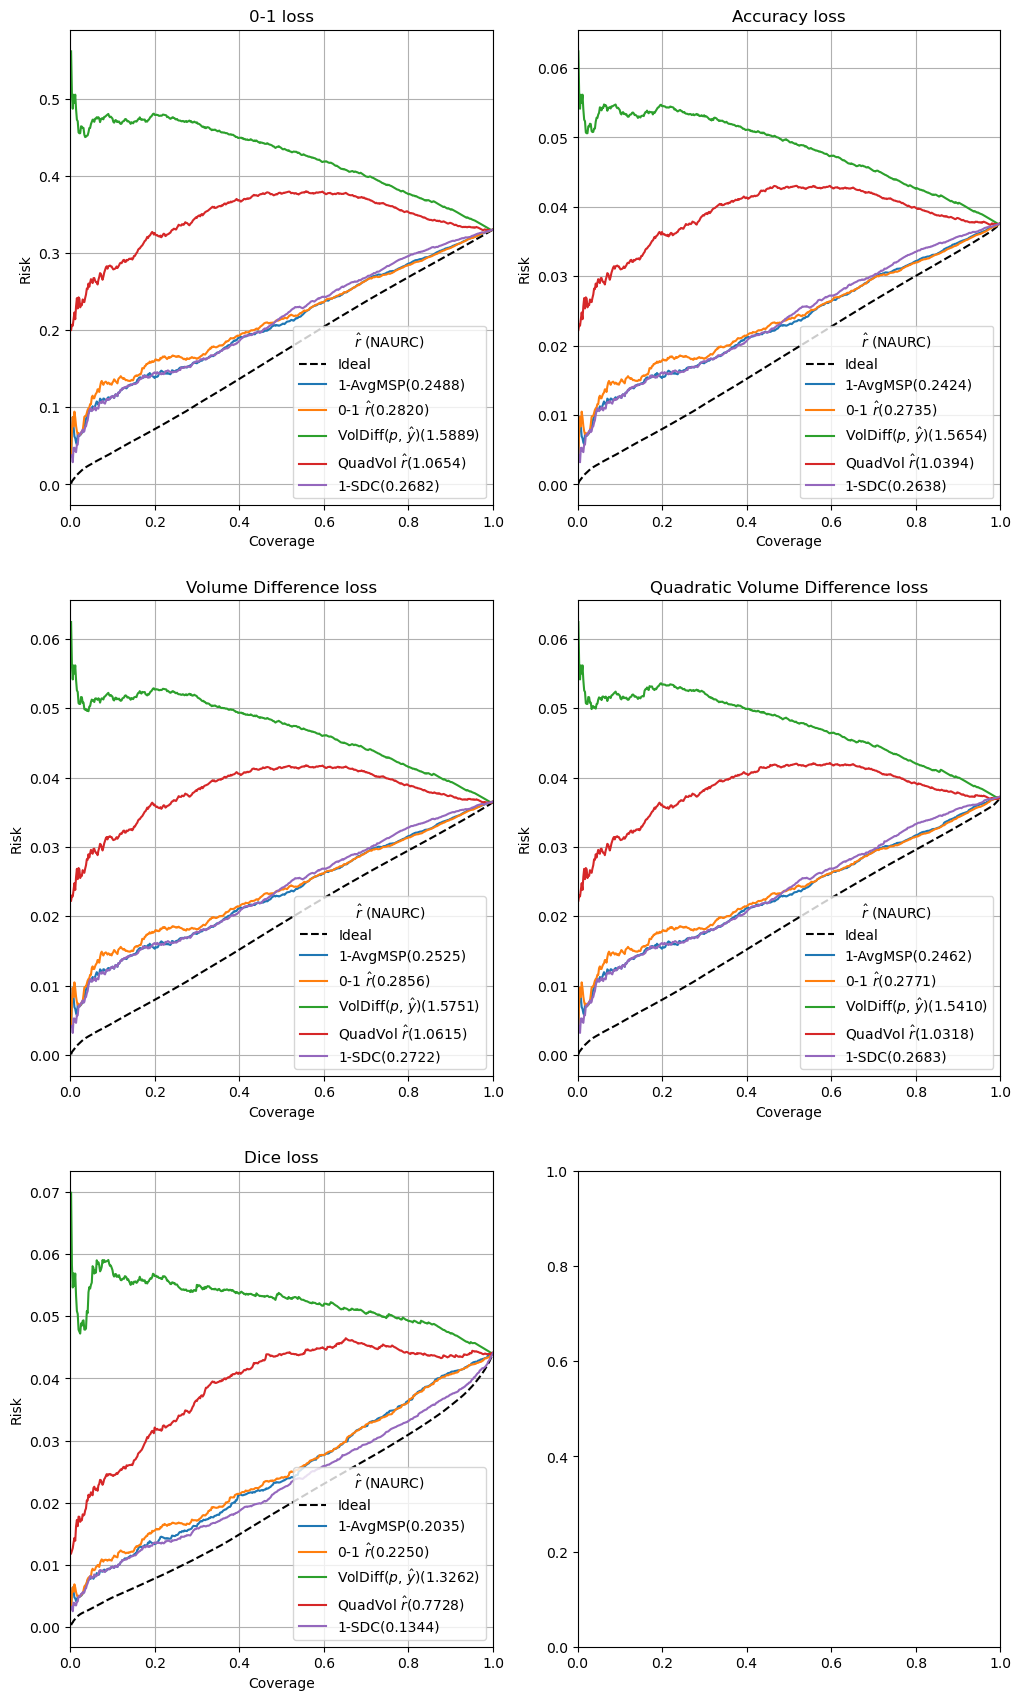

In [28]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

Note that 0-1, accuracy, AVE, and SVE have very similar behavior for the proposed probability distribution.

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [29]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

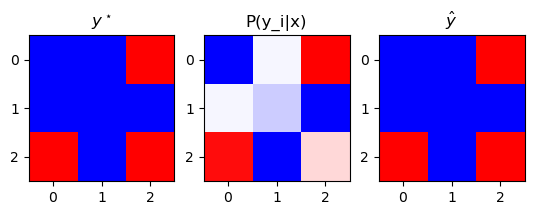

In [30]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

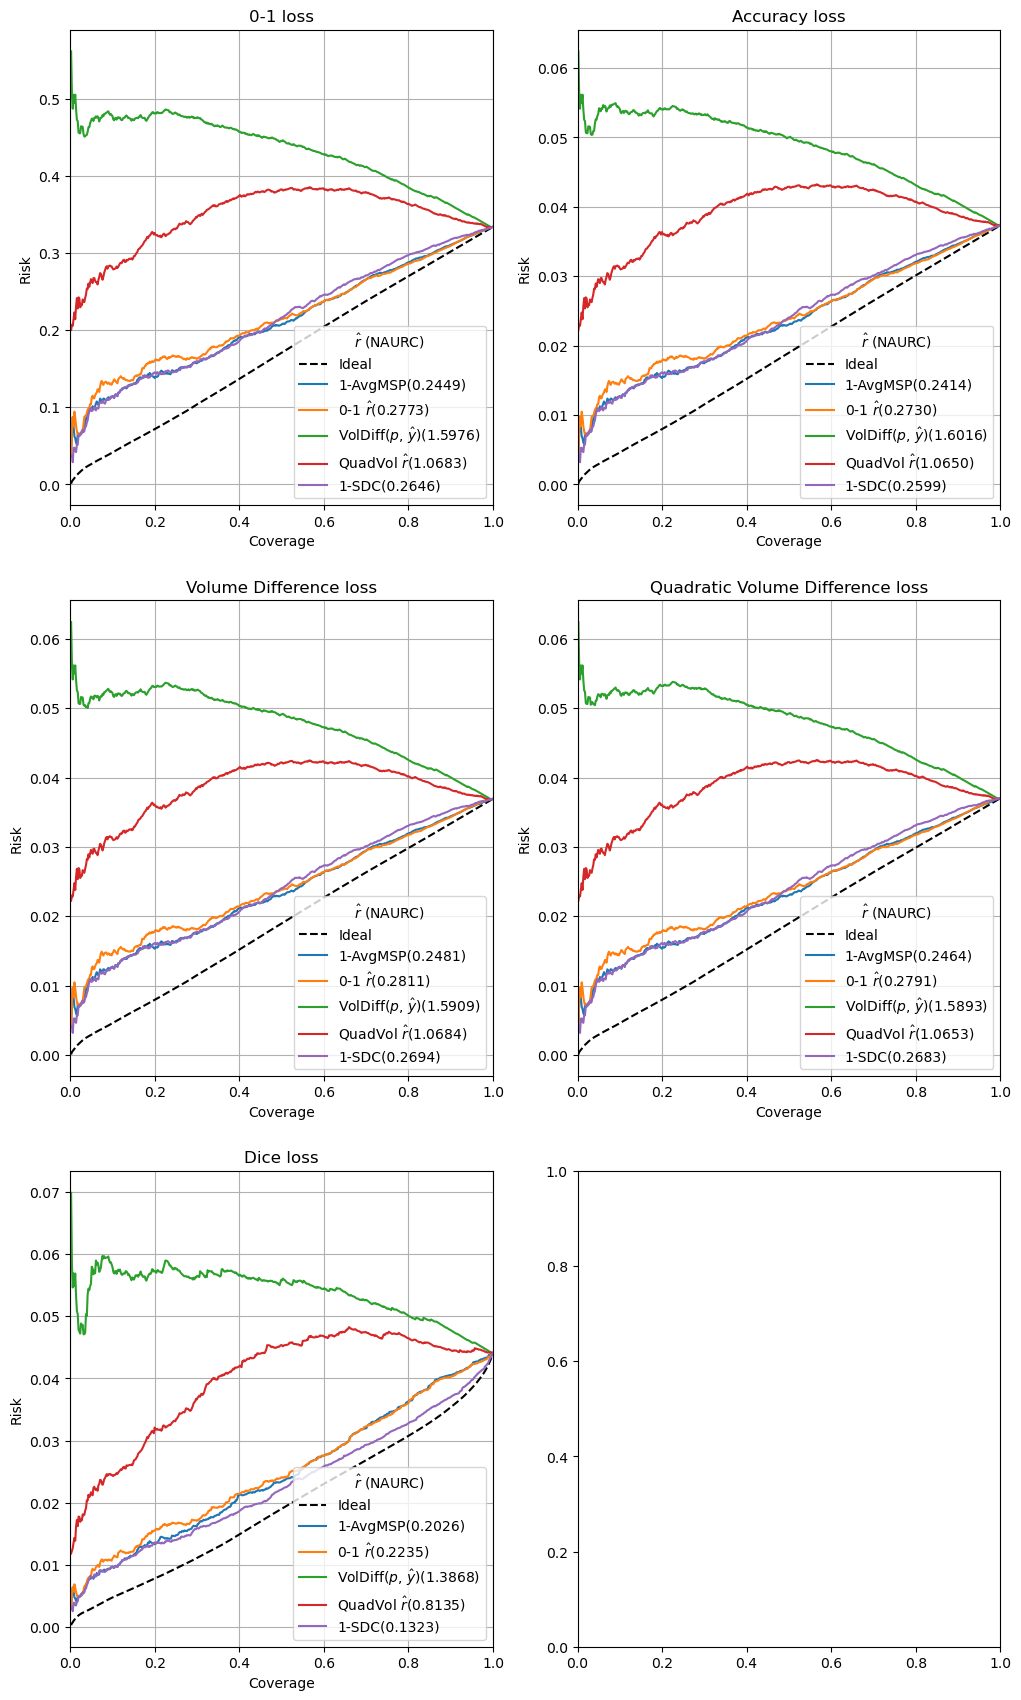

In [31]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Dice-based distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly, and represents the expert segmentation
2. A probability mass is assigned to all images based on their Dice score with respect to $y^{\star}$ 
3. Each segmentation's probability, thus, is defined as $$ P(Y=y|X=x) = \frac{DSC(y,y^\star)}{\sum_{y'\in\mathcal{Y}} DSC(y',y^\star)} $$

In [32]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

Y_images = [int2img(y) for y in range(2**9)]

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)

    My_x = (1 - AllDiceLosses[y_star])

    Py_x = My_x / np.sum(My_x)
    Py.append(Py_x)

    Pyi_x = sum([y_image * p for y_image, p in zip(Y_images, Py_x)])
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

In [33]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

### Example

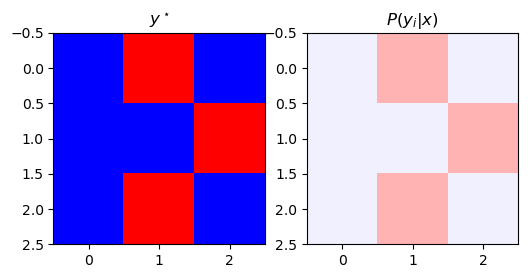

In [34]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(6,6)

y_star = np.argmax(Py[x])

axs[0].imshow(int2img(y_star), vmin=0, vmax=1)
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [35]:
# most probable output
h = lambda x: np.argmax(Py[x])

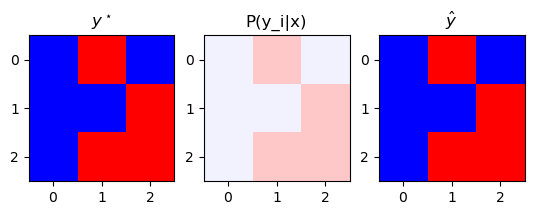

In [36]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

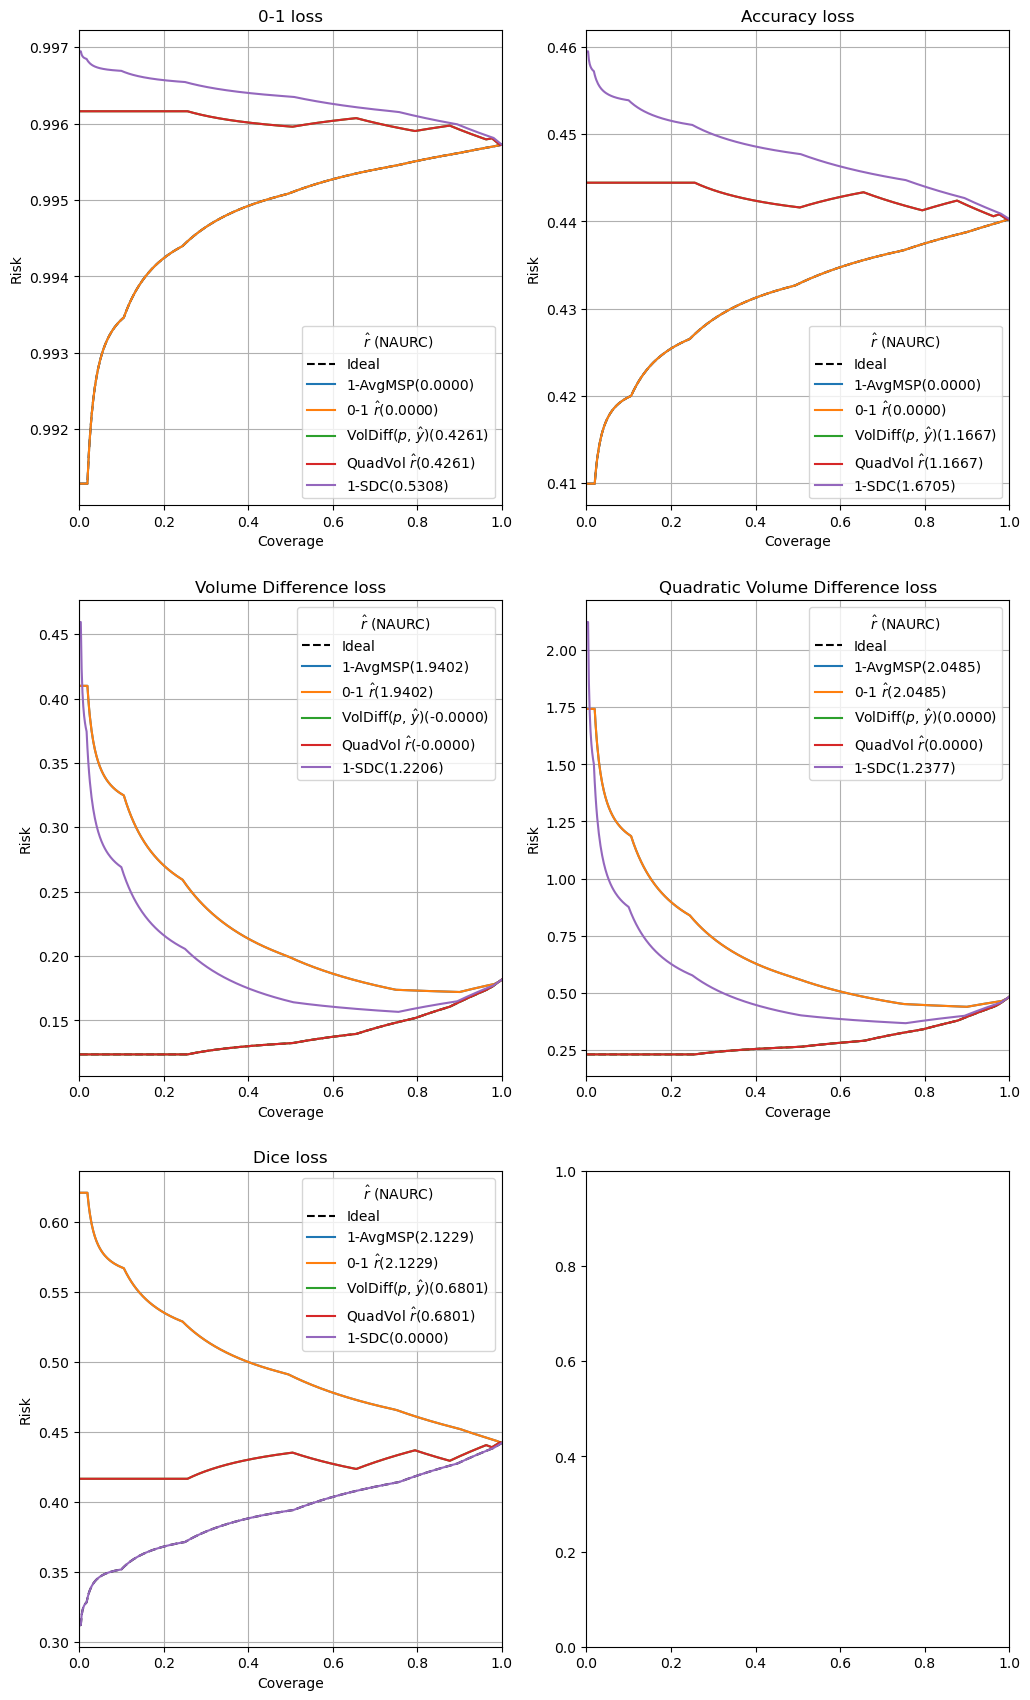

In [37]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [38]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmax(Ry_dice[x])

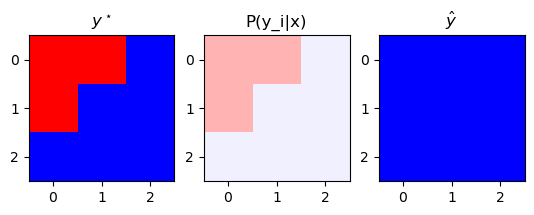

In [39]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat), vmin=0, vmax=1)
axs[2].set_title(r'$\hat{y}$')

plt.show()

Note that, because the probability distribution is based on the Dice score, the prediction that almost always minimizes the risk is the complete foreground image.

#### RC Curves

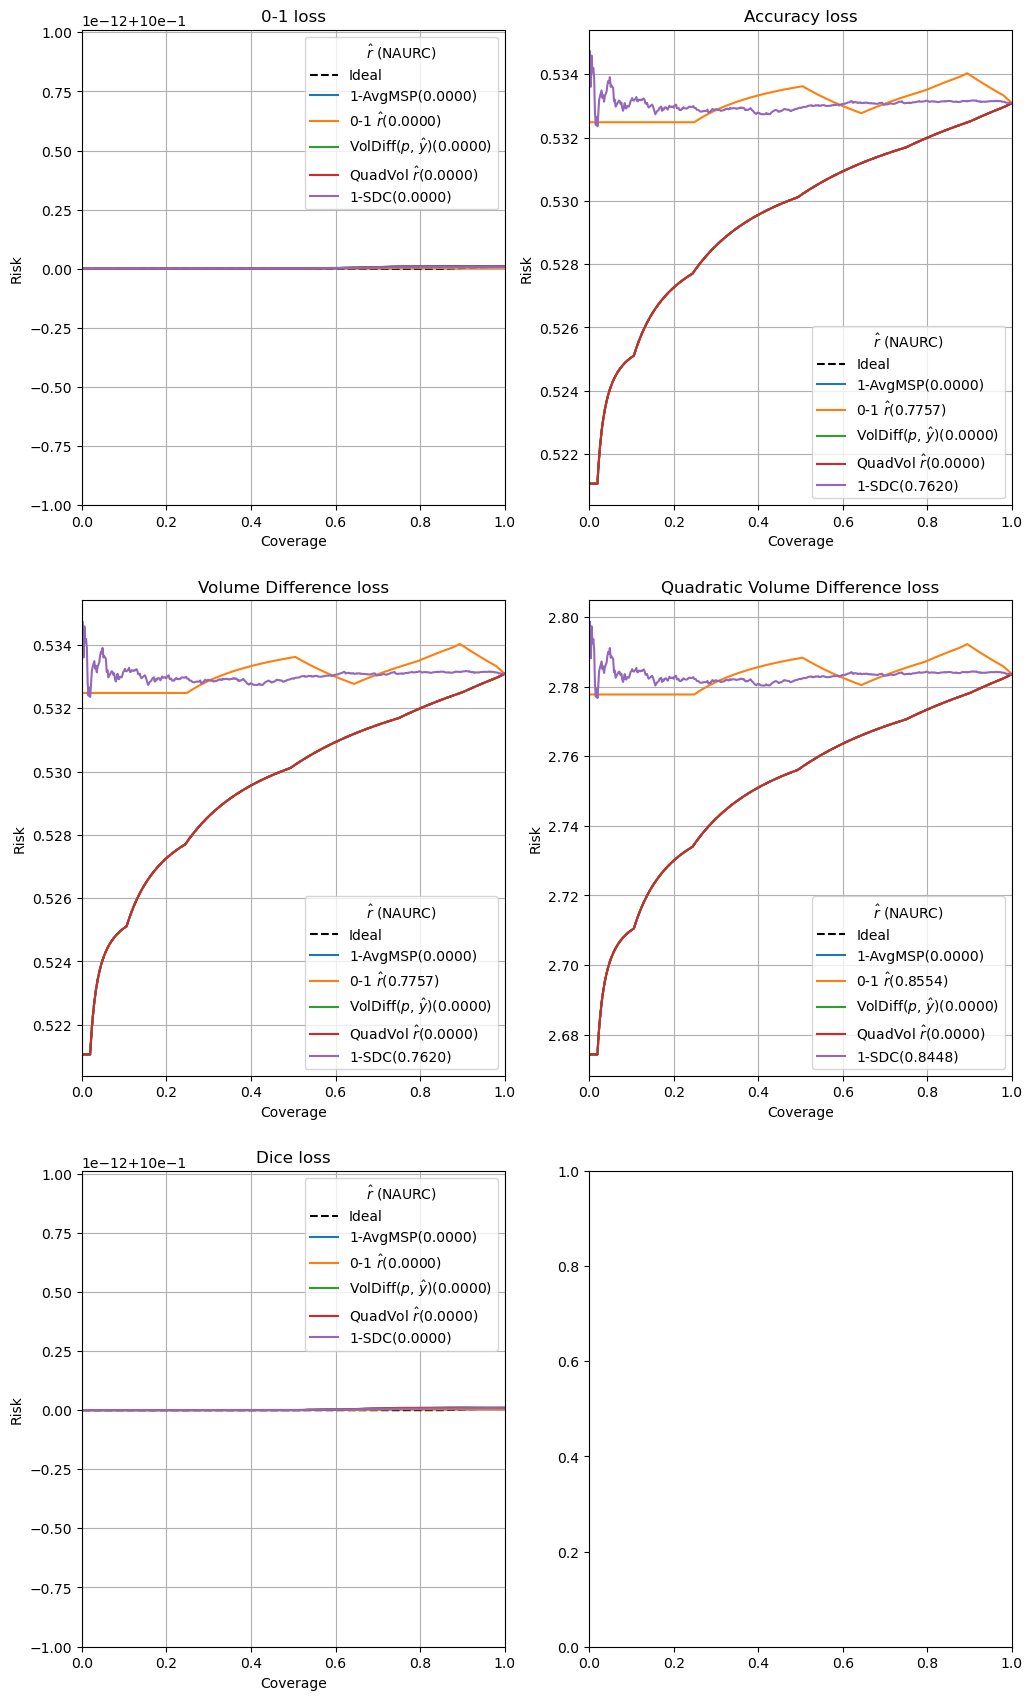

In [40]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Beta distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is an extremely assymetric beta distribution, with $a=0.01$ and $b=10$.

In [41]:
Py = np.array([np.random.RandomState(x).beta(0.01, 10.0, 2**9) for x in range(2**9)])
Py = np.array([Py[x] / Py[x].sum() for x in range(2**9)])

Pyi = np.array([np.array([int2img(y) * Py[x,y] for y in range(2**9)]).sum(0) for x in range(2**9)])

In [42]:
# precompute the risk associated to each y given x
Ry_dice = np.array([AllDiceLosses @ Py[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

### Example

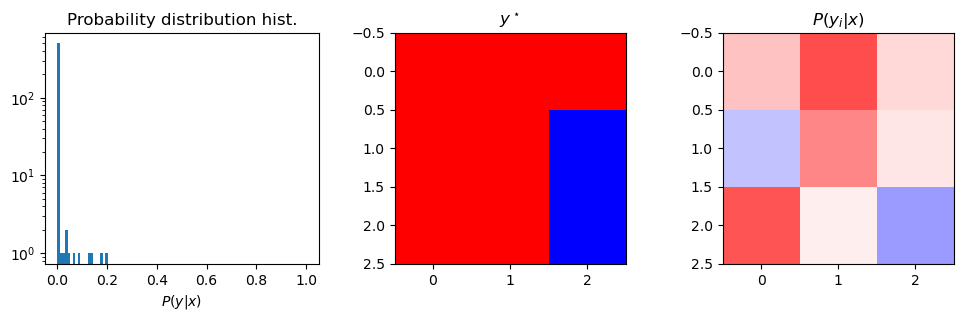

In [43]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])

axs[0].hist(Py[x], bins=np.linspace(0,1,100))
axs[0].set_yscale('log')
axs[0].set_title(r'Probability distribution hist.')
axs[0].set_xlabel(r'$P(y|x)$')

axs[1].imshow(int2img(y_star))
axs[1].set_title(r'$y^\star$')

axs[2].imshow(Pyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$P(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [44]:
# most probable output
h = lambda x: np.argmax(Py[x])

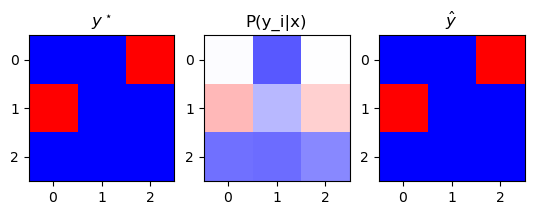

In [45]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

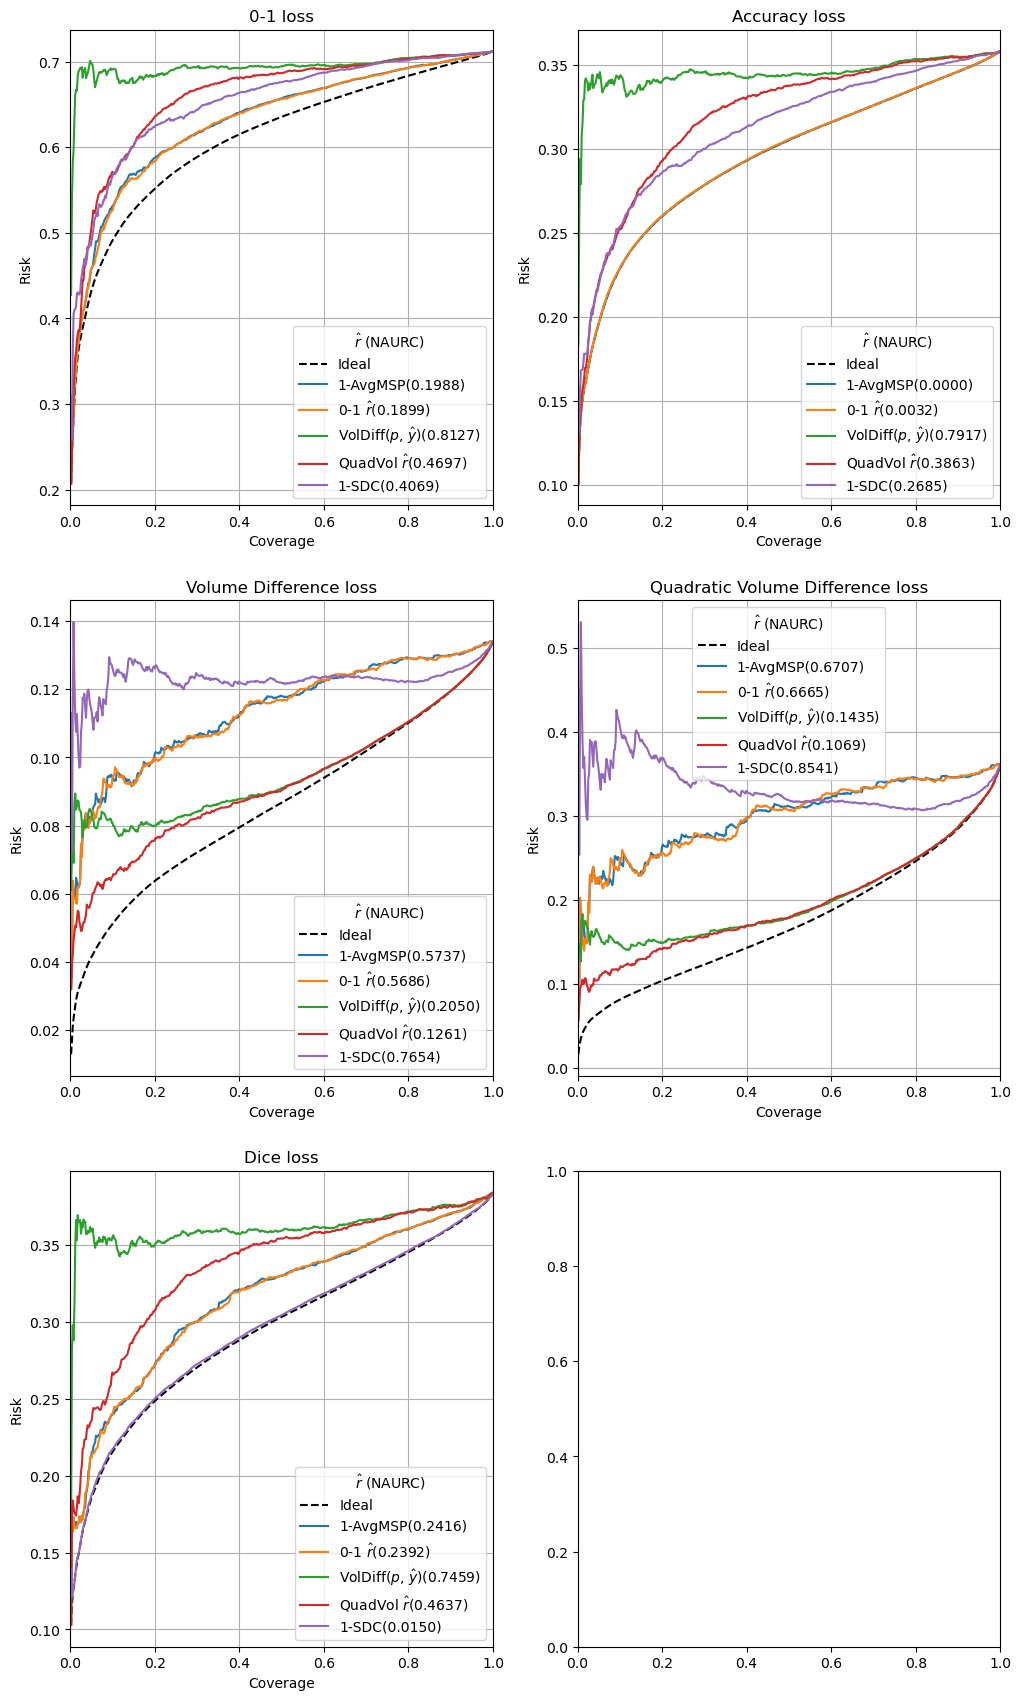

In [46]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [47]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ry_dice[x])

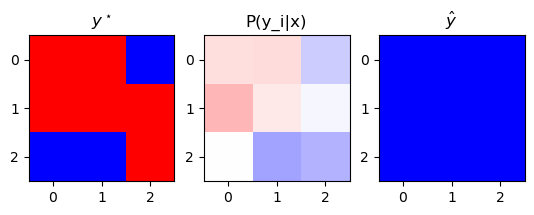

In [48]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 3)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title('P(y_i|x)')

axs[2].imshow(int2img(y_hat))
axs[2].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

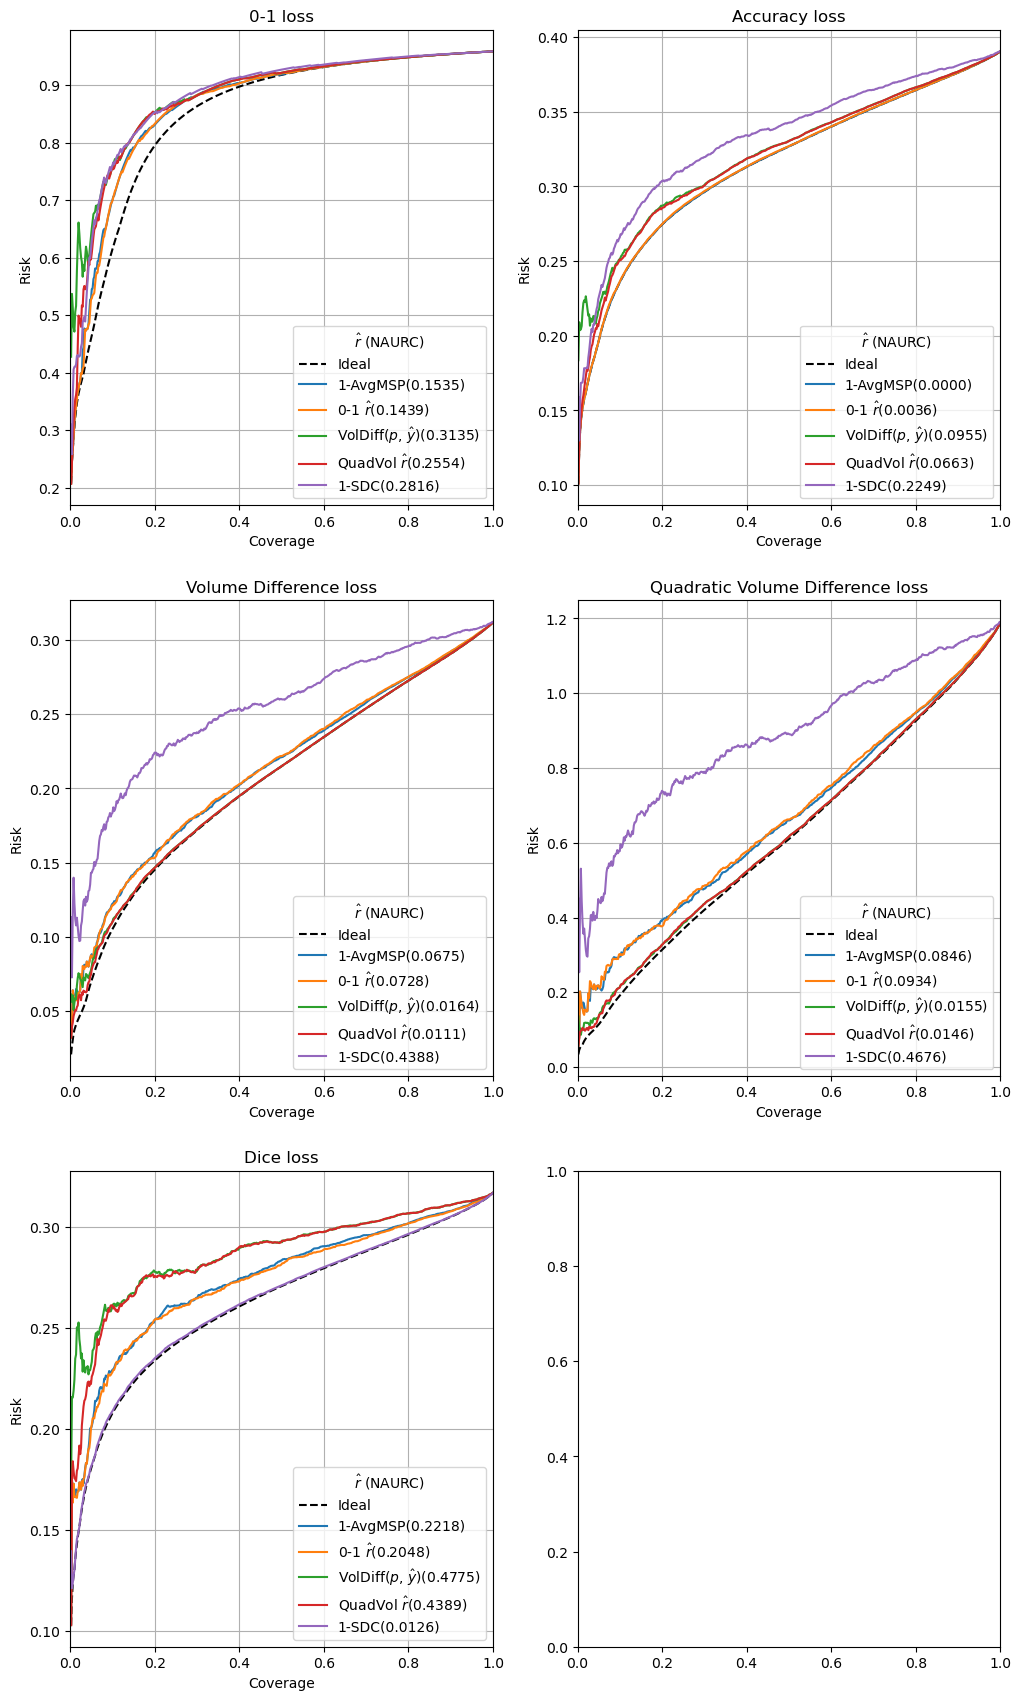

In [49]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

# Comments

TODO